In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures


In [2]:
N = 80
noise_std = 0.20

x = np.linspace(-3, 3, N)
y_clean = np.sin(x)
epsilon = noise_std * np.random.randn(N)
y = y_clean + epsilon

print("x shape:", x.shape)
print("y_clean shape:", y_clean.shape)
print("epsilon shape:", epsilon.shape)
print("y shape:", y.shape)

print("first 5 x:", x[:5])
print("first 5 y:", y[:5])

x shape: (80,)
y_clean shape: (80,)
epsilon shape: (80,)
y shape: (80,)
first 5 x: [-3.         -2.92405063 -2.84810127 -2.7721519  -2.69620253]
first 5 y: [ 0.21169046 -0.13579879 -0.09354848  0.08708466 -0.05729838]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp4_raw_nonlinear_data.png


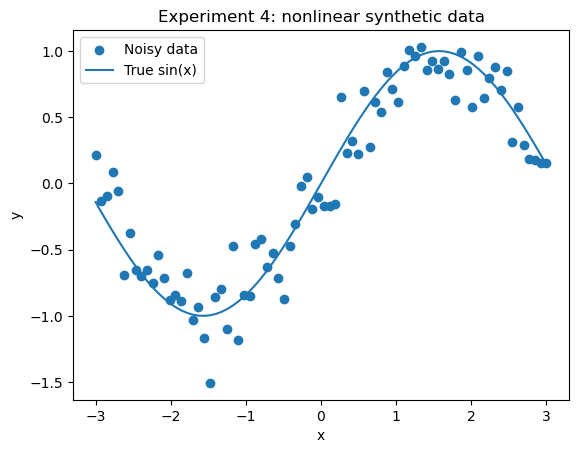

In [3]:
fig, ax = plt.subplots()

ax.scatter(x, y, label="Noisy data")
ax.plot(x, y_clean, label="True sin(x)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 4: nonlinear synthetic data")
ax.legend()

fig_path = FIGURE_DIR / "exp4_raw_nonlinear_data.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [4]:
indices = np.random.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

x_train = x[train_idx]
y_train = y[train_idx]

x_val = x[val_idx]
y_val = y[val_idx]

x_test = x[test_idx]
y_test = y[test_idx]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (48,)
y_train shape: (48,)
x_val shape: (16,)
y_val shape: (16,)
x_test shape: (16,)
y_test shape: (16,)


In [5]:
def make_polynomial_features(x_values, poly_degree, x_scale=3.0):
    """
    Construct polynomial design matrix:
    [1, z, z^2, ..., z^degree]
    where z = x / x_scale
    """

    z = x_values / x_scale

    columns = []

    for power in range(poly_degree + 1):
        columns.append(z ** power)

    Phi = np.column_stack(columns)
    return Phi

x_train shape: (48,)
Phi_train_demo shape: (48, 4)
First 5 rows:
[[ 1.00000000e+00 -4.17721519e-01  1.74491267e-01 -7.28887573e-02]
 [ 1.00000000e+00 -3.79746835e-02  1.44207659e-03 -5.47624022e-05]
 [ 1.00000000e+00 -4.93670886e-01  2.43710944e-01 -1.20312998e-01]
 [ 1.00000000e+00 -7.72151899e-01  5.96218555e-01 -4.60371289e-01]
 [ 1.00000000e+00  9.74683544e-01  9.50008012e-01  9.25957176e-01]]


[]

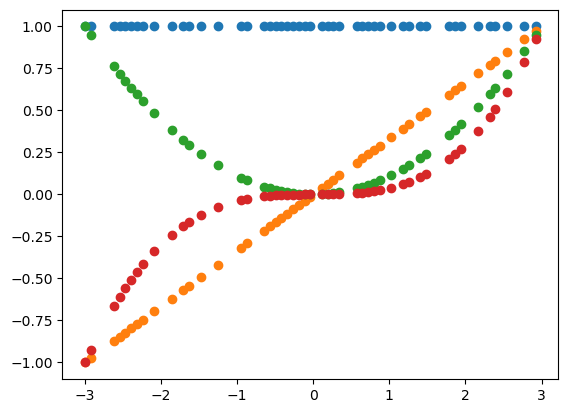

In [6]:
degree = 3

Phi_train_demo = make_polynomial_features(x_train, degree)

print("x_train shape:", x_train.shape)
print("Phi_train_demo shape:", Phi_train_demo.shape)
print("First 5 rows:")
print(Phi_train_demo[:5])

fig,ax = plt.subplots()

ax.scatter(x_train, Phi_train_demo[:,0])
ax.scatter(x_train, Phi_train_demo[:,1])
ax.scatter(x_train, Phi_train_demo[:,2])
ax.scatter(x_train, Phi_train_demo[:,3])

plt.plot()

In [7]:
def mse(y_true, y_pred):
    errors = y_pred - y_true
    return np.mean(errors ** 2)

In [8]:
degrees = [1,2,3,10,20]

results = {}

for degree in degrees:
    Phi_train = make_polynomial_features(x_train,degree)
    Phi_val = make_polynomial_features(x_val, degree)

    theta_hat , residuals, rank, singular_values = np.linalg.lstsq(Phi_train, y_train, rcond = None)

    y_pred_train = Phi_train @ theta_hat
    y_pred_val = Phi_val @ theta_hat

    train_mse = mse(y_train, y_pred_train)
    val_mse = mse(y_val, y_pred_val)

    results[degree] = {'theta_hat':theta_hat,'train_mse':train_mse,'val_mse':val_mse,'rank':rank,'singular_values': singular_values}

    print(f"Degree {degree}")
    print("  Phi_train shape:", Phi_train.shape)
    print("  theta_hat shape:", theta_hat.shape)
    print("  Train MSE:", train_mse)
    print("  Validation MSE:", val_mse)
    print("  Rank:", rank)
    print()

Degree 1
  Phi_train shape: (48, 2)
  theta_hat shape: (2,)
  Train MSE: 0.2026997652597565
  Validation MSE: 0.18879219335561498
  Rank: 2

Degree 2
  Phi_train shape: (48, 3)
  theta_hat shape: (3,)
  Train MSE: 0.20056699068999126
  Validation MSE: 0.20713667464833901
  Rank: 3

Degree 3
  Phi_train shape: (48, 4)
  theta_hat shape: (4,)
  Train MSE: 0.03555793327174495
  Validation MSE: 0.04087494940300071
  Rank: 4

Degree 10
  Phi_train shape: (48, 11)
  theta_hat shape: (11,)
  Train MSE: 0.030085723335695827
  Validation MSE: 0.037969217065322095
  Rank: 11

Degree 20
  Phi_train shape: (48, 21)
  theta_hat shape: (21,)
  Train MSE: 0.025345961941554317
  Validation MSE: 3.3387095457560627
  Rank: 21



Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp4_train_val_mse_vs_degree.png


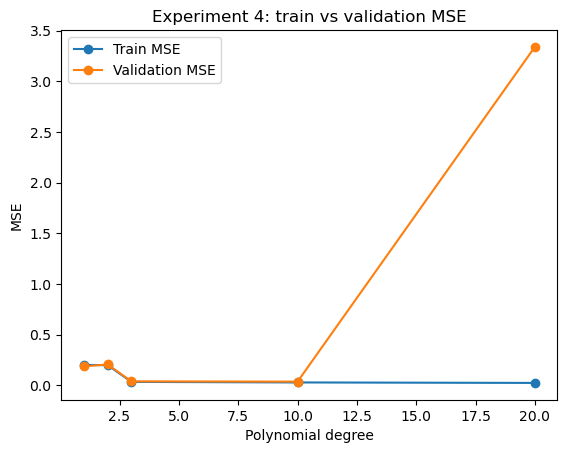

In [9]:
train_mse_values = [results[degree]["train_mse"] for degree in degrees]
val_mse_values = [results[degree]["val_mse"] for degree in degrees]

fig, ax = plt.subplots()

ax.plot(degrees, train_mse_values, marker="o", label="Train MSE")
ax.plot(degrees, val_mse_values, marker="o", label="Validation MSE")

ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_title("Experiment 4: train vs validation MSE")
ax.legend()

fig_path = FIGURE_DIR / "exp4_train_val_mse_vs_degree.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [10]:
best_degree = min(degrees, key=lambda degree: results[degree]["val_mse"])

print("Best degree by validation MSE:", best_degree)
print("Best validation MSE:", results[best_degree]["val_mse"])
print("Train MSE at best degree:", results[best_degree]["train_mse"])

Best degree by validation MSE: 10
Best validation MSE: 0.037969217065322095
Train MSE at best degree: 0.030085723335695827


In [11]:
theta_best = results[best_degree]["theta_hat"]

Phi_test_best = make_polynomial_features(x_test, best_degree)
y_pred_test = Phi_test_best @ theta_best

test_mse = mse(y_test, y_pred_test)

print("Selected degree:", best_degree)
print("Test MSE:", test_mse)
print("y_pred_test shape:", y_pred_test.shape)

Selected degree: 10
Test MSE: 0.08241447772952795
y_pred_test shape: (16,)


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp4_best_model_prediction_vs_truth.png


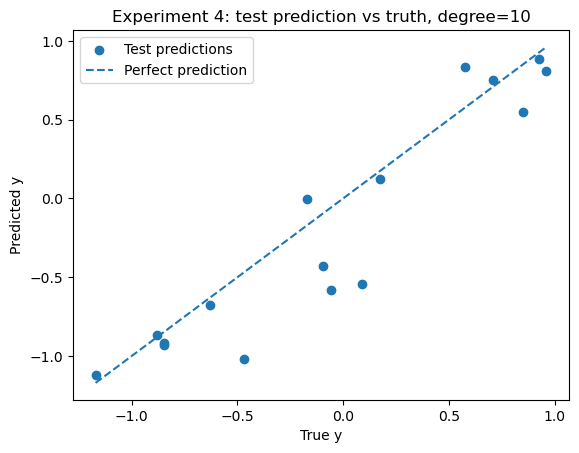

In [12]:
fig, ax = plt.subplots()

ax.scatter(y_test, y_pred_test, label="Test predictions")

min_value = min(y_test.min(), y_pred_test.min())
max_value = max(y_test.max(), y_pred_test.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True y")
ax.set_ylabel("Predicted y")
ax.set_title(f"Experiment 4: test prediction vs truth, degree={best_degree}")
ax.legend()

fig_path = FIGURE_DIR / "exp4_best_model_prediction_vs_truth.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()